<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB12 · Flechas: los vectores

**Parte 2 · Matemáticas y herramientas para robots — Lección 1**

> Terminaste la Parte 1 con un logro enorme: un entorno de aprendizaje por refuerzo hecho por ti, y un
> ordenador que **aprendió solo** a mantener un palo de pie girando **2 ruedecillas**. Pero también vimos el
> límite: el humanoide necesita **miles** de ruedecillas, y para eso hacen falta **matemáticas**.

Empieza la **Parte 2**. Aquí vamos a construir, desde cero, las matemáticas que mueven a los robots y a la
inteligencia artificial. No te asustes: vamos a ir **igual de despacio** que con la programación, con dibujos,
con ejemplos del robot, y comprobándolo todo con código que ya sabes escribir.

La primera herramienta es la más importante de todas: la **flecha**, que los matemáticos llaman **vector**.
Al terminar esta lección entenderás por qué los ingenieros dicen que la observación del humanoide es "una
flecha en un espacio de 45 dimensiones"... y verás que no es tan raro como suena.

Esta lección mezcla teoría y código. Primero, como siempre, la idea.


## 1 · Números que no bastan

Si te digo "**camina 3 metros**", ¿dónde acabas? No lo sabes: ¿hacia delante?, ¿hacia la izquierda?, ¿hacia
atrás? Con un solo número no basta. Necesitas **cuánto** y **hacia dónde**.

Muchas cosas de un robot son así:

- La **velocidad** del torso (NB02 ya lo dijo: "lo deprisa que vas, **y hacia dónde**").
- Un **empujón** (una fuerza): no es lo mismo que te empujen de frente que de lado.
- El **viento** del palo de escoba (NB11): soplaba hacia un lado o hacia el otro.
- Un **paso**: el pie se mueve tantos centímetros, en tal dirección.

Para todas esas cantidades usamos un dibujo que todo el mundo entiende: una **flecha**. La **longitud** de la
flecha dice **cuánto**, y hacia donde **apunta**, dice **hacia dónde**.

```
     ──────►            ───────────►             ▲
                                                 │
     flecha corta       flecha larga             │   flecha que apunta
     (poca velocidad)   (mucha velocidad)        │   hacia otro lado
```

En el palo de escoba todo pasaba en **una sola dirección** (izquierda o derecha), y por eso nos bastaba un
número con signo (+ hacia un lado, − hacia el otro, NB03). Pero un robot que anda se mueve por un **suelo**,
que tiene **dos** direcciones (adelante-atrás e izquierda-derecha). Y para eso, un número no da abasto.


## 2 · El plano y las coordenadas: jugando a "Hundir la flota"

¿Has jugado alguna vez a **"Hundir la flota"**? Cada jugador tiene una cuadrícula, y para disparar dices una
casilla con **dos** datos: una letra (la columna) y un número (la fila), como "B-4". Con dos datos, cualquier
casilla queda localizada sin dudas.

Las matemáticas hacen lo mismo, pero con dos números. Se dibujan dos líneas que se cruzan en ángulo recto:

```
              y (hacia la izquierda del robot)
              ▲
            4 ┤
            3 ┤           ● el punto (5, 3):
            2 ┤             5 hacia delante, 3 hacia la izquierda
            1 ┤
   ───────────┼───┬───┬───┬───┬───┬────► x (hacia delante)
            0 │   1   2   3   4   5
              │
         el ORIGEN (0, 0): donde empieza todo
```

- La línea horizontal es el **eje x**. En robótica, casi siempre significa **hacia delante**.
- La vertical es el **eje y**. Para un robot, **hacia la izquierda**.
- El cruce de las dos es el **origen**, el punto (0, 0).
- Cualquier punto se describe con **dos números entre paréntesis**: primero cuánto en x, luego cuánto en y.
  Se llaman sus **coordenadas**. El punto (5, 3) está 5 hacia delante y 3 hacia la izquierda.

Al suelo cuadriculado con sus dos ejes se le llama **plano cartesiano**, por el filósofo francés René
Descartes, que tuvo la idea hace casi 400 años. (Cuenta la leyenda que se le ocurrió mirando una mosca que
caminaba por el techo y pensando cómo describir dónde estaba en cada momento.)


## 3 · La flecha: cuánto en x y cuánto en y

Una flecha se describe igual que un punto, con **dos números**, pero significan otra cosa: **cuánto se mueve**
en x y **cuánto se mueve** en y, desde donde empiece.

```
                   ▲ y
                   │
                   │        punta
                   │       ↗
                   │     ↗      la flecha (3, 2):
                   │   ↗  2       3 hacia delante
                   │ ↗    ↑       2 hacia la izquierda
                   ● ─ ─ ─┘
                 cola  3
   ────────────────┼──────────────────► x
```

A esos dos números se les llama las **componentes** de la flecha. La flecha (3, 2) significa "**3 hacia
delante y 2 hacia la izquierda**".

Un detalle muy importante: **una flecha no tiene "sitio"**. La flecha (3, 2) es la misma la dibujes donde la
dibujes: empezando en el origen, o empezando en el punto (10, 7). Lo que la define es **cuánto se mueve y hacia
dónde**, no dónde empieza. Es como la instrucción "camina 3 pasos al frente y 2 a la izquierda": vale igual
estés donde estés.

Y en Python, ¿cómo guardamos una flecha? Con lo que ya sabes: una **lista** de dos números (NB09):


In [1]:
flecha = [3, 2]
print("Componente x:", flecha[0])
print("Componente y:", flecha[1])

Componente x: 3
Componente y: 2


La componente x es el elemento 0 de la lista y la y, el elemento 1 (contamos desde 0, como siempre). Ahora
vamos a **dibujarla**.


## 4 · Una herramienta para dibujar

Hasta ahora todo eran números. Pero las flechas piden a gritos un **dibujo**. Python tiene un módulo (NB11)
buenísimo para dibujar gráficos, que se llama **matplotlib**. Como su nombre es largo, hay una costumbre que
sigue todo el mundo: al importarlo, se le pone un **apodo** corto con la palabra **`as`** ("como"):


In [2]:
import matplotlib.pyplot as plt

Se lee: "importa la parte `pyplot` de matplotlib, **y llámala `plt`**". A partir de aquí, cada vez que
escribamos `plt.algo`, estaremos usando una herramienta de dibujo. (`pyplot` es la parte de matplotlib que
sirve para hacer dibujos sencillos; `plt` es el apodo que usa todo el mundo, en cualquier libro o web que
mires.)

Para no repetir los mismos detalles en cada dibujo, nos fabricamos **tres funciones** (NB10). No hace falta que
memorices las herramientas de matplotlib que usan por dentro: los comentarios explican qué hace cada línea, y
nosotros solo usaremos las tres funciones.


In [3]:
def nuevo_dibujo(minimo, maximo):
    plt.figure(figsize=(5, 5))                  # un lienzo cuadrado
    plt.grid(True, alpha=0.4)                   # la cuadrícula, suavecita
    plt.axhline(0, color="gray")                # el eje x
    plt.axvline(0, color="gray")                # el eje y
    plt.xlim(minimo, maximo)                    # hasta dónde se ve en x
    plt.ylim(minimo, maximo)                    # y en y
    plt.gca().set_aspect("equal")               # que un metro mida igual en x que en y

def flecha_desde(origen, vector, color):
    # dibuja la flecha 'vector' empezando en el punto 'origen'
    plt.arrow(origen[0], origen[1], vector[0], vector[1],
              head_width=0.25, length_includes_head=True, color=color)

def punto(p, color):
    plt.plot(p[0], p[1], "o", color=color)      # un puntito redondo

Y ahora, la flecha (3, 2), dibujada empezando en el origen. Al final de cada dibujo se llama a
**`plt.show()`** ("muestra"), que es la orden que enseña el lienzo terminado:


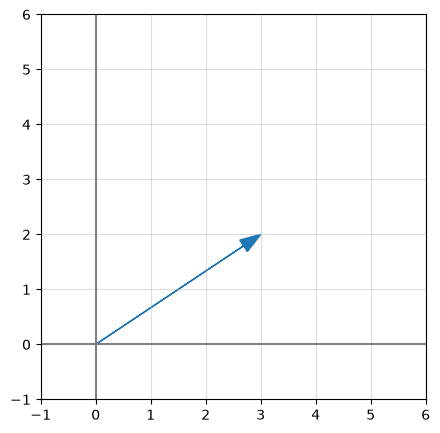

In [4]:
nuevo_dibujo(-1, 6)
flecha_desde([0, 0], [3, 2], "tab:blue")
plt.show()

Ahí está: 3 cuadritos hacia delante (x) y 2 hacia arriba (y). Recuerda que una flecha no tiene sitio: dibujemos
**la misma** flecha (3, 2) empezando en dos lugares distintos:


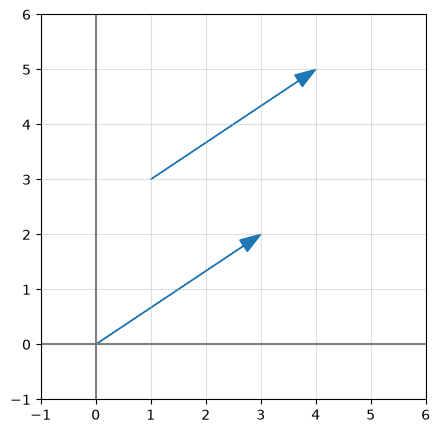

In [5]:
nuevo_dibujo(-1, 6)
flecha_desde([0, 0], [3, 2], "tab:blue")
flecha_desde([1, 3], [3, 2], "tab:blue")
plt.show()

Dos flechas **paralelas** y **iguales**: misma longitud, misma dirección. Para las matemáticas, son **la misma
flecha** dibujada en dos sitios.


## 5 · Sumar flechas: una detrás de otra

Imagina que un robot da **dos pasos**: el primero, la flecha (3, 1); el segundo, la flecha (1, 2). ¿Dónde acaba?
Se dibuja la segunda flecha **empezando donde acaba la primera** (la cola de una en la punta de la otra). La flecha
que va del principio al final es la **suma**:

```
   suma de flechas = ponerlas una detrás de otra (punta con cola)
```

Y en números, sumar flechas es facilísimo: **se suman las x entre sí y las y entre sí**.

```
     (3, 1)
   + (1, 2)
   ────────
     (4, 3)        3 + 1 = 4 en x;  1 + 2 = 3 en y
```

En Python, una función que sume dos flechas **componente a componente** (de cualquier tamaño, gracias al
`range(len(...))` del NB09):


In [6]:
def sumar(a, b):
    resultado = []
    for i in range(len(a)):
        resultado.append(a[i] + b[i])
    return resultado

print(sumar([3, 1], [1, 2]))

[4, 3]


**[4, 3]**. Ahora, el dibujo. En azul el primer paso, en naranja el segundo (empezando en la punta del primero,
que está en (3, 1)), y en verde la suma, del principio al final:


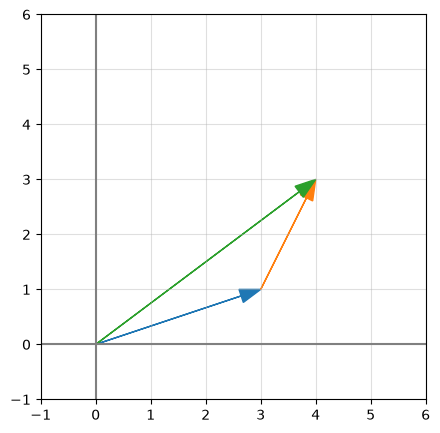

In [7]:
primer_paso = [3, 1]
segundo_paso = [1, 2]
total = sumar(primer_paso, segundo_paso)

nuevo_dibujo(-1, 6)
flecha_desde([0, 0], primer_paso, "tab:blue")
flecha_desde(primer_paso, segundo_paso, "tab:orange")
flecha_desde([0, 0], total, "tab:green")
plt.show()

La flecha verde es el atajo: ir directamente del principio al final. Da lo mismo dar los dos pasos que dar el
paso verde.

**¿Para qué sirve sumar flechas en un robot?** Para muchísimas cosas:

- **Juntar movimientos:** varios pasos seguidos se suman para saber cuánto se ha desplazado el robot en total.
- **Juntar fuerzas:** si el motor empuja hacia delante y el viento empuja de lado, la fuerza total es la suma
  de las dos flechas. Es lo que hace el simulador en el paso 1 del NB02 ("mira **todas** las fuerzas").
- **Mover cosas:** posición nueva = posición + desplazamiento. La cadena de oro del NB02, ahora con flechas.

Por ejemplo, un robot que da **cuatro pasitos** algo torcidos (los pasos de verdad nunca son perfectos). ¿Dónde
acaba? Un acumulador (NB07) de flechas: empezamos en el origen y vamos sumando:


In [8]:
pasos = [[0.6, 0.1], [0.5, -0.1], [0.7, 0.0], [0.6, 0.2]]

posicion = [0, 0]
for p in pasos:
    posicion = sumar(posicion, p)

print("Posición final:", posicion)

Posición final: [2.4, 0.2]


El robot ha avanzado **2,4 metros** hacia delante y se ha desviado **0,2** hacia la izquierda. Es exactamente lo
que hace un robot de verdad para saber dónde está, sumando sus propios pasos: se llama **odometría** (de las
palabras griegas para "camino" y "medida"). Y tiene un problema que ya imaginarás: los pequeños errores de cada
paso se van **acumulando** (como el ruido de los decimales del NB07), así que, tras muchos pasos, el robot ya no
sabe bien dónde está.


## 6 · Multiplicar una flecha por un número

Si multiplicas una flecha por un número, **cada componente se multiplica** por ese número. ¿Qué le pasa a la
flecha?

- Por **2**: el **doble de larga**, misma dirección.
- Por **0,5**: la **mitad**, misma dirección.
- Por **−1**: misma longitud, pero **al revés** (¡los negativos del NB03: "lo mismo, en sentido contrario"!).

```
   2 × (3, 1) = (6, 2)        0,5 × (3, 1) = (1,5; 0,5)        −1 × (3, 1) = (−3, −1)
```

A esto los matemáticos lo llaman **multiplicar por un escalar** (un número normal, sin dirección, se llama
**escalar**, porque solo "escala": agranda o encoge). En Python:


In [9]:
def escalar(numero, a):
    resultado = []
    for x in a:
        resultado.append(numero * x)
    return resultado

print(escalar(2, [3, 1]))
print(escalar(0.5, [3, 1]))
print(escalar(-1, [3, 1]))

[6, 2]
[1.5, 0.5]
[-3, -1]


Y dibujadas, todas desde el origen: en azul la original, en verde el doble, en naranja la mitad y en rojo la
del revés:


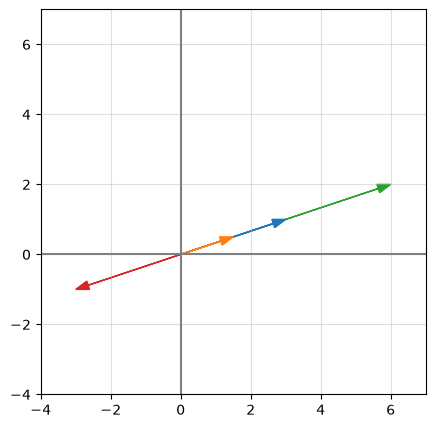

In [10]:
original = [3, 1]
nuevo_dibujo(-4, 7)
flecha_desde([0, 0], escalar(2, original), "tab:green")
flecha_desde([0, 0], original, "tab:blue")
flecha_desde([0, 0], escalar(0.5, original), "tab:orange")
flecha_desde([0, 0], escalar(-1, original), "tab:red")
plt.show()

Todas están sobre la **misma línea**: multiplicar por un número nunca cambia la dirección (como mucho, le da la
vuelta). Solo cambia **cuánto**.

En robótica se usa constantemente: "la velocidad del motor, **el doble**"; "frena **a la mitad**"; "empuja **en
contra**" (multiplicar por un número negativo, como el `-30 * inclinacion` del palo de escoba, que era empujar en
contra de la inclinación y 30 veces más fuerte).


## 7 · Restar flechas: ¿cómo llego de aquí a allí?

Restar es la pregunta inversa a sumar: si estoy en el punto **A** y quiero ir al punto **B**, ¿qué flecha tengo que
recorrer? La respuesta es **B − A**: el destino menos el origen.

```
   flecha de A a B = B − A        (siempre "destino menos origen")
```

Por ejemplo, un robot en A = (2, 1) que quiere llegar a una meta en B = (6, 4):

```
     (6, 4)    ← meta
   − (2, 1)    ← donde estoy
   ────────
     (4, 3)    ← lo que tengo que recorrer: 4 hacia delante y 3 a la izquierda
```

Restar es sumar la flecha "al revés" (multiplicada por −1), así que podemos construir `restar` con las dos
funciones que ya tenemos (¡funciones que usan funciones, NB10!):


Para llegar a la meta hay que recorrer: [4, 3]


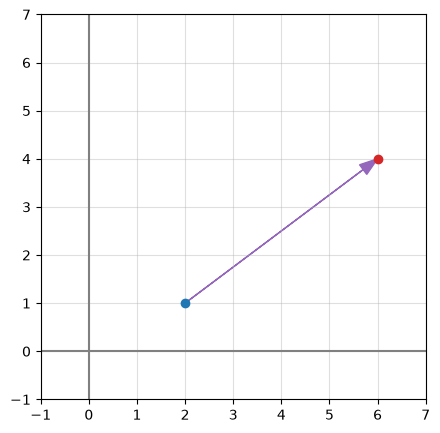

In [11]:
def restar(a, b):
    return sumar(a, escalar(-1, b))

robot = [2, 1]
meta = [6, 4]
hacia_la_meta = restar(meta, robot)
print("Para llegar a la meta hay que recorrer:", hacia_la_meta)

nuevo_dibujo(-1, 7)
punto(robot, "tab:blue")
punto(meta, "tab:red")
flecha_desde(robot, hacia_la_meta, "tab:purple")
plt.show()

El punto azul es el robot, el rojo la meta, y la flecha morada, **el camino de uno a otro**: (4, 3).

Esta resta es una de las cosas que más hace un robot que se mueve: "¿dónde está mi objetivo **respecto a mí**?".
Una flecha que va de uno mismo a la meta. Y con ella surge la pregunta natural: **¿a qué distancia está?**


## 8 · ¿Cuánto mide una flecha? Pitágoras desde cero

La flecha (4, 3) va 4 hacia delante y 3 hacia la izquierda. Pero ¿cuánto **mide**, en línea recta? No es 4 + 3 =
7: eso sería ir primero 4 al frente y **luego** 3 a la izquierda, dando un rodeo. El atajo en diagonal es más
corto.

Fíjate en el dibujo: la flecha, junto con sus dos componentes, forma un **triángulo** con una esquina en ángulo
recto (como la esquina de un folio):

```
                    ●
                  ↗ │
      la flecha ↗   │ 3   (componente y)
     (¿cuánto?) ↗   │
              ↗     │
            ●───────┘  ← esquina en ángulo recto
                4
          (componente x)
```

Hace unos **2.500 años**, en la antigua Grecia, a la escuela de **Pitágoras** se le atribuye una regla preciosa
para este tipo de triángulos (aunque los babilonios ya la usaban mucho antes):

> **En un triángulo con una esquina recta, el lado largo al cuadrado es igual a la suma de los cuadrados de los
> otros dos.**

¿Recuerdas el cuadrado (NB04, NB06)? Es un número multiplicado por sí mismo, y se llama así porque es el área de
un **cuadrado** con ese lado. La regla de Pitágoras dice, literalmente: si construyes un cuadrado sobre cada lado del
triángulo, **los dos cuadrados pequeños juntos tienen tantos cuadraditos como el grande**.

```
   lado de 3  →  cuadrado de 3 × 3 =  9 cuadraditos
   lado de 4  →  cuadrado de 4 × 4 = 16 cuadraditos
                                    ──
                        9 + 16   =  25 cuadraditos  →  el lado largo es el número que,
                                                       al cuadrado, da 25... ¡el 5! (5 × 5 = 25)
```

Así que la flecha (4, 3) mide **5**. El atajo en diagonal (5) es más corto que el rodeo (4 + 3 = 7), como debe ser.


### La raíz cuadrada: el cuadrado al revés

En el último paso hemos hecho una operación nueva: buscar "**el número que, al cuadrado, da 25**". Es la operación
contraria a elevar al cuadrado, y se llama **raíz cuadrada**. Se escribe con el símbolo √:

```
   √25 = 5     porque 5 × 5 = 25
   √9  = 3     porque 3 × 3 = 9
   √2  = 1,414...   (no es un número "redondo": 1,414 × 1,414 ≈ 2)
```

En Python, la raíz cuadrada se calcula elevando **a 0,5** (es un truco de matemáticas que entenderás más adelante;
por ahora, tómalo como una receta): `x ** 0.5`.


In [12]:
print(25 ** 0.5)
print(9 ** 0.5)
print(2 ** 0.5)

5.0
3.0
1.4142135623730951


**5.0, 3.0 y 1.414...** (decimales, porque `** 0.5` siempre da decimal).

Ya podemos escribir la **longitud** de una flecha: cada componente al cuadrado, todo sumado, y la raíz cuadrada
del total. Fíjate en que la primera parte es **idéntica** al cálculo del esfuerzo de los motores (NB09): ¡el
esfuerzo era la longitud al cuadrado de la flecha de acciones!


In [13]:
def longitud(a):
    total = 0
    for x in a:
        total = total + x ** 2
    return total ** 0.5

print("Longitud de (4, 3):", longitud([4, 3]))
print("Longitud de (1, 1):", longitud([1, 1]))

Longitud de (4, 3): 5.0
Longitud de (1, 1): 1.4142135623730951


(4, 3) mide **5**, y (1, 1) mide **1,414**: un paso de 1 al frente y 1 a la izquierda recorre, en diagonal, algo
más de 1,4.

A la longitud de una flecha también se le llama **módulo** o **norma** del vector. Para un robot, es la respuesta a
preguntas como:

- ¿**A qué distancia** está la meta? → la longitud de la flecha "meta − yo".
- ¿**Cómo de rápido** va el torso, sin importar hacia dónde? → la longitud de la flecha velocidad. (Esto se llama
  **rapidez**: la velocidad sin la dirección.)
- ¿**Cuánto** empuja en total un conjunto de motores? → la longitud de la flecha de acciones.


## 9 · Más allá de dos: flechas en 3, en 17 y en 45 dimensiones

El suelo tiene dos direcciones, pero el mundo tiene **tres**: adelante-atrás, izquierda-derecha y **arriba-abajo**.
Para el torso del humanoide, que también sube y baja, hacen falta tres números: (x, y, z), donde la nueva
componente, **z**, significa **hacia arriba**. Se llama una flecha en
**tres dimensiones** (3D). Y lo bonito es que **todo funciona igual**: sumar componente a componente, multiplicar
cada componente, y la longitud con Pitágoras (sumando **tres** cuadrados). Nuestras funciones ya sirven, porque las
escribimos con `range(len(...))` y bucles sobre la lista: valen para flechas de **cualquier** tamaño.

Por ejemplo, un torso que se mueve a 1 m/s hacia delante y sube un poquito, 0,2 m/s:


In [14]:
velocidad_torso = [1.0, 0.0, 0.2]     # (adelante, izquierda, arriba): x, y, z
print("Rapidez del torso:", round(longitud(velocidad_torso), 3), "m/s")

Rapidez del torso: 1.02 m/s


**1,02 m/s**: casi todo es avance, con un pelín de subida.

¿Y con **más** de tres? No podemos dibujar una flecha en 4 dimensiones, ni en 45: nuestro cerebro solo imagina 3. Pero
**las reglas siguen funcionando igual**, y eso es lo que importa. Una lista de 17 números (la acción del humanoide) es
una flecha en 17 dimensiones; una lista de 45 (su observación) es una flecha en 45 dimensiones. Se suman igual, se
multiplican igual, y miden lo que diga Pitágoras con 45 cuadrados.

> **"Vector" = una lista de números con la que se puede sumar, multiplicar por un número y medir.** Da igual que
> tenga 2 números o 45.

¿Para qué sirve la longitud en 45 dimensiones, si no se puede dibujar? Para algo muy útil: **medir lo distintas que son
dos situaciones**. La distancia entre dos observaciones (la longitud de su resta) es pequeña si las dos situaciones se
parecen, y grande si son muy distintas. Un ejemplo con 3 números (altura del torso, inclinación, velocidad de giro):


In [15]:
de_pie = [1.40, 0.0, 0.1]
casi_igual = [1.38, 0.05, 0.12]
cayendose = [0.90, 0.6, -2.0]

print("Distancia de 'de pie' a 'casi igual':", round(longitud(restar(casi_igual, de_pie)), 3))
print("Distancia de 'de pie' a 'cayéndose': ", round(longitud(restar(cayendose, de_pie)), 3))

Distancia de 'de pie' a 'casi igual': 0.057
Distancia de 'de pie' a 'cayéndose':  2.241


0,057 frente a 2,24: la segunda situación está **40 veces más lejos**. Esto es justo lo que necesita una mente que
aprende para **generalizar** (NB11): si una situación nueva está **cerca** de otras que ya conoce, probablemente le
convenga una acción **parecida**. Las redes neuronales funcionan, en buena parte, gracias a esta idea.


## 10 · Mini-proyecto: un robot que camina hacia su meta

Juntemos todo. Un robot de juguete está en el origen, (0, 0), y quiere llegar a una meta en (8, 6). En cada paso:

1. Calcula la flecha **hacia la meta** (meta − posición; **restar**).
2. Mide **a qué distancia** está (**longitud**). Si está a menos de medio metro, ha llegado (`break`, NB08).
3. Da un paso de **0,5 metros** en esa dirección. Para eso, encoge la flecha hacia la meta hasta que mida 0,5: la
   multiplica por 0,5 / distancia (**escalar**). (Si la flecha mide 10 y la multiplicas por 0,5/10 = 0,05, pasa a
   medir 0,5. Siempre funciona.)
4. Pero sopla un **viento** constante hacia un lado, la flecha (0; −0,15), que lo desvía un poco en cada paso
   (**sumar**).

Guardamos todas las posiciones en una lista (NB09) para dibujar el camino:


In [16]:
posicion = [0.0, 0.0]
meta = [8.0, 6.0]
viento = [0.0, -0.15]
camino = [posicion]

for n in range(100):
    hacia_la_meta = restar(meta, posicion)
    distancia = longitud(hacia_la_meta)
    if distancia < 0.5:
        print("¡Ha llegado! Pasos dados:", n, "| distancia final:", round(distancia, 2), "m")
        break
    paso = escalar(0.5 / distancia, hacia_la_meta)     # un paso de 0,5 m hacia la meta
    posicion = sumar(sumar(posicion, paso), viento)    # avanza... y el viento lo desvía
    camino.append(posicion)

¡Ha llegado! Pasos dados: 25 | distancia final: 0.35 m


¡Llega en **25 pasos**! Dibujemos el camino. Para unir los puntos con una línea, usamos `plt.plot` con dos listas: todas
las x y todas las y del camino (las sacamos con un bucle):


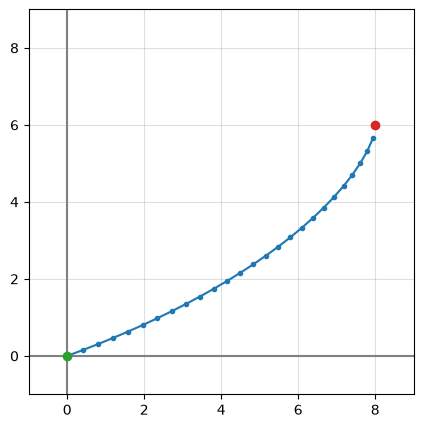

In [17]:
xs = []
ys = []
for p in camino:
    xs.append(p[0])
    ys.append(p[1])

nuevo_dibujo(-1, 9)
plt.plot(xs, ys, "o-", color="tab:blue", markersize=3)    # el camino, punto a punto
punto([0, 0], "tab:green")                                # la salida
punto(meta, "tab:red")                                    # la meta
plt.show()

Fíjate en la forma del camino: **no es una línea recta**. Como el viento lo empuja todo el rato hacia abajo, el robot
va quedando por **debajo** de la línea recta hacia la meta. Pero en cada paso **vuelve a calcular** la dirección hacia la
meta desde donde está, así que va **corrigiendo** sin parar, y al final llega.

¿Te suena? Es una **política** (NB03): en cada paso mira la observación (dónde está la meta respecto a él) y decide una
acción (hacia dónde dar el paso). Es una política de **control clásico**, escrita a mano con flechas. Y gracias a que
corrige en cada paso, **aguanta las perturbaciones** (el viento), igual que el palo de escoba aguantaba el suyo.


## 11 · Resumen de la lección

1. Muchas cantidades de un robot tienen **cuánto y hacia dónde** (velocidades, fuerzas, pasos): se representan con
   **flechas**, o **vectores**. En el **plano cartesiano**, un punto o una flecha se describen con sus **coordenadas** o
   **componentes**: (x, y). Una flecha no tiene "sitio".
2. **Sumar** flechas = ponerlas punta con cola; en números, sumar componente a componente. Sirve para juntar pasos
   (**odometría**), fuerzas y movimientos.
3. **Multiplicar por un escalar** agranda, encoge o da la vuelta a una flecha, sin cambiar su línea. **Restar** da la
   flecha "de A a B" = **B − A** (destino menos origen).
4. La **longitud** de una flecha, por **Pitágoras**: raíz cuadrada (`** 0.5`) de la suma de los cuadrados de sus
   componentes. Da distancias y **rapideces**.
5. Todo funciona igual en **3, 17 o 45 dimensiones**: la acción y la observación del humanoide son vectores, y la
   distancia entre dos observaciones mide **lo distintas que son dos situaciones**.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Vector** | Una flecha: una lista de números con la que se suma, se multiplica y se mide. |
| **Plano cartesiano** | El "suelo cuadriculado" con un eje x y un eje y. |
| **Origen** | El punto (0, 0), donde se cruzan los ejes. |
| **Coordenadas / componentes** | Los números que describen un punto / una flecha: (x, y). |
| **Escalar** | Un número normal, sin dirección; multiplicar por él agranda o encoge una flecha. |
| **Odometría** | Saber dónde estás sumando tus propios pasos. |
| **Teorema de Pitágoras** | En un triángulo rectángulo, lado largo² = suma de los otros dos al cuadrado. |
| **Raíz cuadrada (√)** | El número que, al cuadrado, da el que tienes: √25 = 5. En Python, `** 0.5`. |
| **Longitud / módulo / norma** | Cuánto mide una flecha. |
| **Rapidez** | La longitud de la velocidad: cuán rápido, sin importar hacia dónde. |
| **Dimensión** | Cuántos números tiene un vector (2D, 3D, 45D...). |
| **matplotlib / `plt`** | El módulo de dibujo de Python, con su apodo habitual. |


## 12 · Ejercicios

**E1.** Sin ordenador: ¿cuál es la suma de las flechas (2, 5) y (−1, 3)? ¿Y 3 × (2, −1)?

**E2.** Un robot está en (1, 1) y su meta en (4, 5). ¿Qué flecha tiene que recorrer? ¿A qué distancia está la meta?
Hazlo a mano y compruébalo con las funciones.

**E3.** Calcula a mano la longitud de (6, 8). Pista: piensa en el triángulo 3-4-5... ¡duplicado!

**E4.** ¿Cuánto mide la flecha (0, −7)? ¿Y (−3, −4)? ¿Puede una longitud ser negativa?

**E5.** Un robot da estos tres pasos: (1, 0), (0, 1), (−1, 0). ¿Dónde acaba? ¿Qué distancia ha recorrido **en total**
(sumando lo que mide cada paso) y a qué distancia ha quedado del origen? ¿Por qué son distintas?

**E6.** En el mini-proyecto, cambia el viento a (0; −0,4). ¿Llega el robot a la meta? ¿Tarda más o menos? ¿Y con un
viento de (0; −0,6), más fuerte que el propio paso? Piensa qué pasará antes de ejecutarlo.

**E7.** La rapidez de una persona andando es de algo más de 1 m/s. Si la velocidad del torso de un robot es
(0,8; 0,6; 0,0), ¿anda más rápido o más despacio que una persona?


<details>
<summary>▶ Solución E1</summary>

- (2, 5) + (−1, 3) = (2 − 1, 5 + 3) = **(1, 8)**.
- 3 × (2, −1) = (3 × 2, 3 × (−1)) = **(6, −3)**: el triple de larga, misma dirección.
</details>

<details>
<summary>▶ Solución E2</summary>

Flecha: meta − robot = (4 − 1, 5 − 1) = **(3, 4)**. Distancia: √(3² + 4²) = √(9 + 16) = √25 = **5**.

```python
hacia = restar([4, 5], [1, 1])
print(hacia, longitud(hacia))
```

Salida: `[3, 4] 5.0`.
</details>

<details>
<summary>▶ Solución E3</summary>

√(6² + 8²) = √(36 + 64) = √100 = **10**. Es el triángulo 3-4-5 con todos los lados el doble: 6-8-10. (Multiplicar una
flecha por 2 multiplica su longitud por 2.)
</details>

<details>
<summary>▶ Solución E4</summary>

- (0, −7) mide √(0 + 49) = **7**.
- (−3, −4) mide √(9 + 16) = **5**.

Una longitud **nunca** es negativa: al elevar al cuadrado, los signos desaparecen (menos por menos da más), así que
sumamos siempre números positivos o cero. El signo de las componentes dice **hacia dónde**; la longitud solo dice
**cuánto**.
</details>

<details>
<summary>▶ Solución E5</summary>

Suma: (1, 0) + (0, 1) + (−1, 0) = **(0, 1)**: acaba en (0, 1). Distancia **recorrida**: cada paso mide 1, así que
**3** metros en total. Distancia **al origen**: la longitud de (0, 1) = **1** metro. Son distintas porque el robot ha
dado un rodeo (avanzó, giró y volvió). La primera es "cuánto has andado"; la segunda, "a qué distancia has quedado".
Un robot que da vueltas en círculo puede andar mucho y no llegar a ningún sitio... ¿te acuerdas del barco tramposo del
NB04?
</details>

<details>
<summary>▶ Solución E6</summary>

Con (0; −0,4) el robot **sigue llegando**, pero tarda más y el camino se curva mucho más (el viento le roba buena parte
de cada paso). Con (0; −0,6) el viento empuja **más** de lo que avanza cada paso (0,5): cuando la meta queda hacia
arriba, el robot no consigue subir, se va quedando cada vez más abajo y **no llega** en los 100 pasos (el bucle se
termina sin el mensaje de "¡Ha llegado!"). Es la lección del motor débil del NB11: si la perturbación es más fuerte que
tu capacidad de corregir, ninguna política te salva.
</details>

<details>
<summary>▶ Solución E7</summary>

Rapidez = √(0,8² + 0,6² + 0²) = √(0,64 + 0,36) = √1 = **1 m/s**. Prácticamente como una persona andando (que va a algo
más de 1 m/s), un poquito más despacio. (Fíjate: 0,8 y 0,6 forman otro triángulo "3-4-5" escondido, dividido entre 5.)
</details>


## 13 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Hoy has aprendido a pensar en **flechas**: sumarlas, estirarlas, medirlas, y a ver la observación del humanoide como
una flecha en 45 dimensiones. En el **NB13** llega la operación de flechas más importante de toda la inteligencia
artificial: el **producto escalar**. Y te va a dar una sorpresa: la política del palo de escoba, `-30 * inclinacion -
8 * velocidad`, era un producto escalar sin que lo supieras... y es exactamente lo que calcula, por dentro, una
**neurona artificial**.
